## Reusable workflow (via utils)

Bruise is 6 days old on 02-06-2026.

This notebook now uses reusable functions from `utils/hsi_utils.py` for loading, calibration, ROI handling, plotting, interactive tools, and SAM.

Loaded folder: 2026-06-02_010
Dark reference shape: (1, 512, 204)
White reference shape: (1, 512, 204)
Sample image shape: (512, 512, 204)


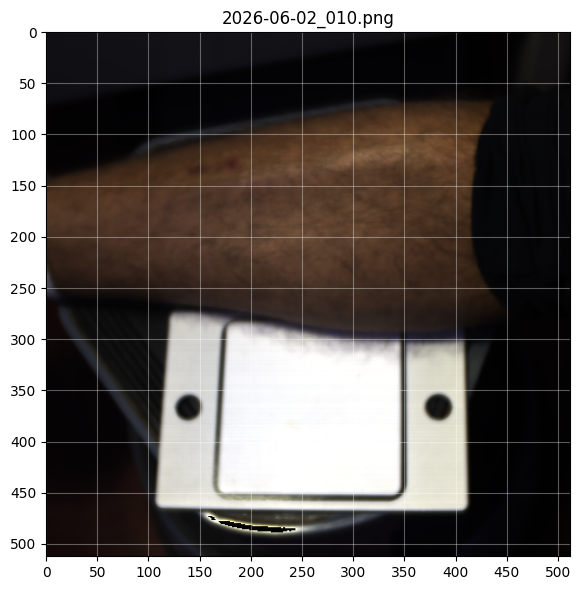

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': '2026-06-02_010.png'}>)

In [1]:
import numpy as np

from utils import (
    load_capture_triplet,
    get_default_wavelengths,
    show_png_with_grid,
    calibrate_data,
    plot_white_dark_spectrum,
    create_roi_crop_rotate_ui,
    visualize_two_point_spectra,
    create_band_slider_ui,
    create_band_ratio_ui,
    run_sam,
)

folder_name = "2026-06-02_010"
sample_data, dark_data, white_data, png_path = load_capture_triplet(folder_name)
wavelengths = get_default_wavelengths(sample_data)

print(f"Loaded folder: {folder_name}")
print(f"Dark reference shape: {dark_data.shape}")
print(f"White reference shape: {white_data.shape}")
print(f"Sample image shape: {sample_data.shape}")

show_png_with_grid(png_path, grid_step=50)

## Calibrate data

In [2]:
calibrated = calibrate_data(sample_data, dark_data, white_data)

print(f"np.mean(sample_data): {np.mean(sample_data):.6f}")
print(f"np.mean(dark_data): {np.mean(dark_data):.6f}")
print(f"np.mean(white_data): {np.mean(white_data):.6f}")
print(f"np.mean(calibrated): {np.mean(calibrated):.6f}")

np.mean(sample_data): 756.599426
np.mean(dark_data): 239.657440
np.mean(white_data): 1991.740234
np.mean(calibrated): 0.305984


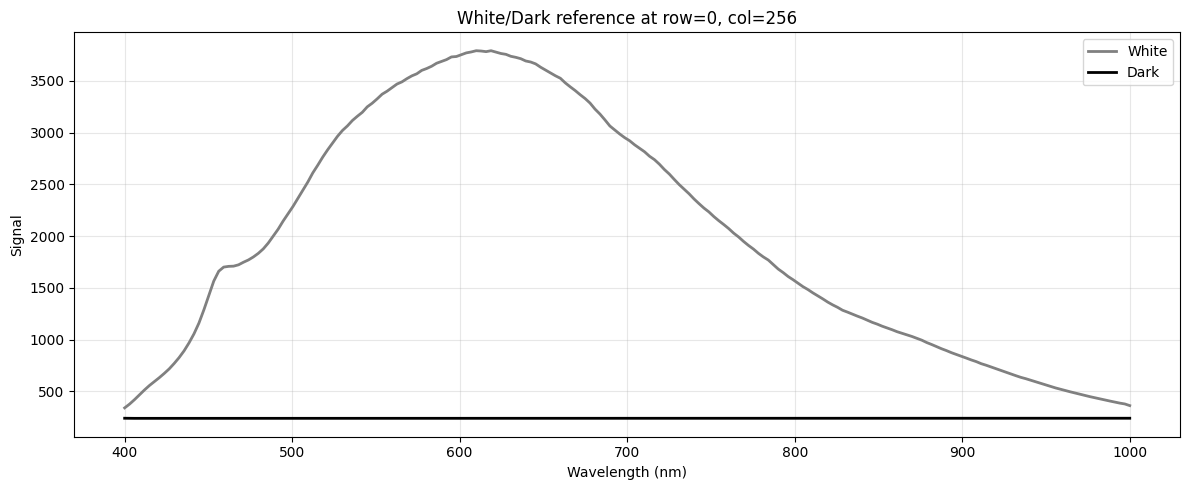

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'White/Dark reference at row=0, col=256'}, xlabel='Wavelength (nm)', ylabel='Signal'>)

In [3]:
plot_white_dark_spectrum(
    white_data=white_data,
    dark_data=dark_data,
    wavelengths=wavelengths,
    row=0,
    col=256,
)

## Crop and rotate ROI, then compare two spectra

calibrated_roi_data shape: (300, 100, 204)


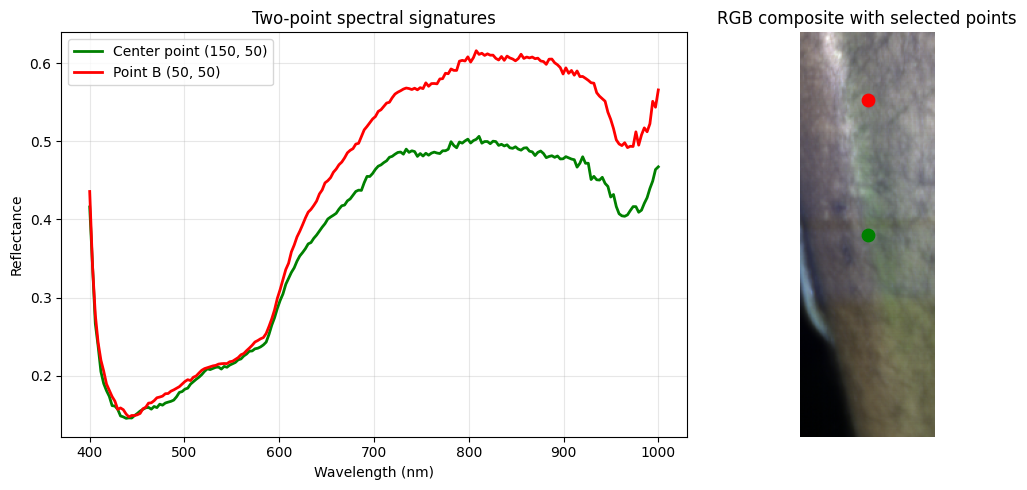

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Two-point spectral signatures'}, xlabel='Wavelength (nm)', ylabel='Reflectance'>,
        <Axes: title={'center': 'RGB composite with selected points'}>],
       dtype=object))

In [8]:
roi_state = create_roi_crop_rotate_ui(
    calibrated_data=calibrated,
    wavelengths=wavelengths,
    initial_y=(200, 500),
    initial_x=(100, 200),
    initial_rotation_k=0,
)

# After adjusting sliders, re-run this cell once to update calibrated_roi_data.
calibrated_roi_data = roi_state["roi"]
print(f"calibrated_roi_data shape: {calibrated_roi_data.shape}")

# Define two points in ROI coordinates and compare spectra
point_a = (calibrated_roi_data.shape[0] // 2, calibrated_roi_data.shape[1] // 2)
point_b = (50, 50)

visualize_two_point_spectra(
    cube=calibrated_roi_data,
    wavelengths=wavelengths,
    point_a=point_a,
    point_b=point_b,
    labels=("Center point", "Point B"),
)

## Interactive single wavelength viewer

In [ ]:
create_band_slider_ui(calibrated_roi_data, wavelengths)

## QUALITY CHECKS


In [6]:


print("\n" + "="*50)
print("CALIBRATION QUALITY CHECKS")
print("="*50)
dark_mean = np.mean(dark_data, axis=(0, 1))
white_mean = np.mean(white_data, axis=(0, 1))
# Check 1: Dark reference should be near zero
dark_mean_value = np.mean(dark_mean)
print(f"Dark reference mean: {dark_mean_value:.4f} (should be near 0)")

# Check 2: White reference should be significantly higher than dark
white_mean_value = np.mean(white_mean)
print(f"White reference mean: {white_mean_value:.4f}")

# Check 3: Dynamic range
dynamic_range = white_mean_value - dark_mean_value
print(f"Dynamic range: {dynamic_range:.4f}")

# Check 4: Calibrated values should be mostly between 0 and 1
valid_pixels = np.sum((calibrated >= 0) & (calibrated <= 1.2))
total_pixels = calibrated.size
percent_valid = 100 * valid_pixels / total_pixels
print(f"Valid calibrated pixels: {percent_valid:.1f}%")

if percent_valid > 95:
    print("\nCalibration quality: EXCELLENT")
elif percent_valid > 85:
    print("\nCalibration quality: GOOD (minor issues)")
else:
    print("\nCalibration quality: POOR (recapture references)")

print("="*50)



CALIBRATION QUALITY CHECKS
Dark reference mean: 239.6574 (should be near 0)
White reference mean: 1991.7402
Dynamic range: 1752.0828
Valid calibrated pixels: 99.9%

Calibration quality: EXCELLENT


## Interactive band ratio (A/B)

In [ ]:
create_band_ratio_ui(calibrated_roi_data, wavelengths)